In [1]:
import torch
import torch.nn as nn

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import numpy as np

import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)
t = np.linspace(0, 100, 500)
data = np.sin(t) + 0.1 * np.random.normal(size=len(t)) 

In [3]:
data = data.reshape(-1, 1)

In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [5]:
def create_sequences(data, sequence_length):
    sequences = []
    for i in range(len(data)-sequence_length):
        seq = data[i:i+sequence_length]
        label = data[i+sequence_length]
        sequences.append((seq, label))
    return sequences

In [6]:
sequence_length = 5
sequences = create_sequences(scaled_data, sequence_length)

In [7]:
X = np.array([seq[0] for seq in sequences])
y = np.array([seq[1] for seq in sequences])

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [10]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True,
        )
        self.fc = nn.Linear(
            hidden_size,
            output_size
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        output = self.fc(out[:,-1,:])
        return output

In [11]:
model = LSTMModel(1, 50, 1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 250

In [12]:
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)   
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()
    print(f"Epoch: {epoch+1} Loss: {loss:.4f}")

Epoch: 1 Loss: 0.4022
Epoch: 2 Loss: 0.3880
Epoch: 3 Loss: 0.3744
Epoch: 4 Loss: 0.3612
Epoch: 5 Loss: 0.3484
Epoch: 6 Loss: 0.3359
Epoch: 7 Loss: 0.3238
Epoch: 8 Loss: 0.3120
Epoch: 9 Loss: 0.3004
Epoch: 10 Loss: 0.2890
Epoch: 11 Loss: 0.2778
Epoch: 12 Loss: 0.2667
Epoch: 13 Loss: 0.2557
Epoch: 14 Loss: 0.2449
Epoch: 15 Loss: 0.2341
Epoch: 16 Loss: 0.2234
Epoch: 17 Loss: 0.2128
Epoch: 18 Loss: 0.2022
Epoch: 19 Loss: 0.1917
Epoch: 20 Loss: 0.1813
Epoch: 21 Loss: 0.1709
Epoch: 22 Loss: 0.1606
Epoch: 23 Loss: 0.1503
Epoch: 24 Loss: 0.1403
Epoch: 25 Loss: 0.1304
Epoch: 26 Loss: 0.1207
Epoch: 27 Loss: 0.1113
Epoch: 28 Loss: 0.1024
Epoch: 29 Loss: 0.0939
Epoch: 30 Loss: 0.0860
Epoch: 31 Loss: 0.0788
Epoch: 32 Loss: 0.0725
Epoch: 33 Loss: 0.0673
Epoch: 34 Loss: 0.0632
Epoch: 35 Loss: 0.0603
Epoch: 36 Loss: 0.0588
Epoch: 37 Loss: 0.0585
Epoch: 38 Loss: 0.0593
Epoch: 39 Loss: 0.0608
Epoch: 40 Loss: 0.0626
Epoch: 41 Loss: 0.0641
Epoch: 42 Loss: 0.0651
Epoch: 43 Loss: 0.0653
Epoch: 44 Loss: 0.06

In [13]:
model.eval()
with torch.no_grad():
    predictions = model(X_test)
    test_loss = criterion(predictions, y_test)
    print(f"Test Loss: {test_loss.item():.4f}")

Test Loss: 0.006018158979713917


In [14]:
predictions_originals = scaler.inverse_transform(predictions.numpy())
test_originals = scaler.inverse_transform(y_test.numpy())

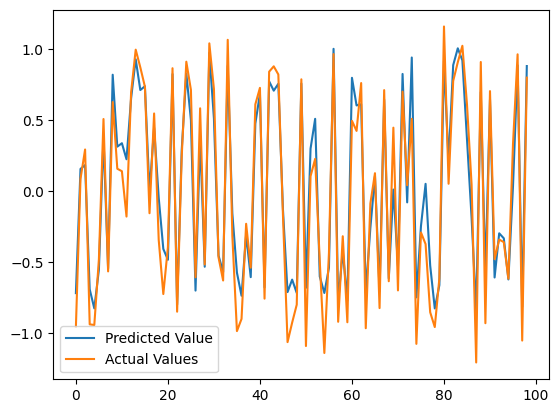

In [15]:
plt.plot(predictions_originals, label="Predicted Value")
plt.plot(test_originals, label="Actual Values")
plt.legend()
plt.show()